# SIPTA — Ingesta y EDA: Salud y Capacidad Hospitalaria
**Proyecto**: Sistema de Indicadores y Priorización Territorial y Alertas Tempranas (DataJam Bogotá)  
**Fase PDCO**: DEVELOPMENT | **Fase CRISP-DM**: Data Understanding / Data Preparation  
**Autoría**: **Persona A (Adan Sánchez — Análisis Exploratorio de Datos / EDA)**  
**Relevamiento de fuentes**: Persona B (Yesid Bello — Data Scientist)  
**Objetivo**: Carga de IPS con urgencias, razón de camas hospitalarias y análisis exploratorio asistencial (EDA).  
**Datos de Entrada**: `data/raw/SALUD/*`  
**Datos de Salida**: `data/processed/SALUD/*`


## 1. Ingesta y Carga de Fuentes de Salud (SaluData / SDS)



# SIPTA Notebook: Ingestión de datos — Salud

## Dominio: Salud

Este notebook documenta la ingesta reproducible del dataset oficial
**Instituciones de Salud con servicios de urgencias en Bogotá D.C.**

### Objetivos

- Cargar el archivo original almacenado en `data/raw/SALUD`.
- Preservar el archivo crudo sin modificaciones.
- Identificar la codificación y estructura necesarias para su lectura.
- Registrar dimensiones, columnas y tipos iniciales.
- Verificar que el dataset queda disponible para la fase posterior de validación.

> En este notebook no se realizan limpieza, integración territorial ni cálculo de indicadores.

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = None
for _p in [Path('.').resolve(), Path('.').resolve().parent, Path('.').resolve().parent.parent]:
    if (_p / 'data' / 'raw').exists() or (_p / 'src').exists():
        PROJECT_ROOT = _p
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path('.').resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
SALUD_DIR = RAW_DIR / "SALUD"

archivo_salud = SALUD_DIR / "osb_ofertasrv-ips-urgencias.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Archivo Salud:", archivo_salud)
print("¿Existe?:", archivo_salud.exists())


PROJECT_ROOT: c:\DataJam_DataOlinguitos_Gen
Archivo Salud: c:\DataJam_DataOlinguitos_Gen\data\raw\SALUD\osb_ofertasrv-ips-urgencias.csv
¿Existe?: True


In [2]:
print("=== ARCHIVO ORIGINAL ===")
print("Nombre:", archivo_salud.name)
print("Tamaño (MB):", round(archivo_salud.stat().st_size / (1024**2), 3))


=== ARCHIVO ORIGINAL ===
Nombre: osb_ofertasrv-ips-urgencias.csv
Tamaño (MB): 0.015


In [3]:
df_salud = pd.read_csv(
    archivo_salud,
    sep=None,
    engine="python",
    encoding="cp1252"
)

df_salud.head()


,OBJECTID,Código IPS,Nombre IPS,Nombre sede,Número sede,Dirección,Telefono contacto,Correco electrónico,Tipo de naturaleza,Latitud,Longitud
0,1,1100105322,Clínica La Inmaculada,Clínica la Inmaculada,1,KR 7 68 70,5870366,inmaculada@clinicalainmaculada.org,Privada,"4,65319721","-74,05726314"
1,2,1100105597,Centro De Atención En Salud Cafam Floresta,Centro de Atención en Salud Cafam Floresta,4,AK 68 90 88,5550700 ext 12017-12015,calidadsalud@cafam.com.co,Privada,"4,685731816","-74,07440845"
2,3,1100105597,Centro De Atención En Salud Cafam Suba,Centro de Atención en Salud Cafam Suba,11,KR 113 C 142 A 98,5550700 ext 12017-12015,calidadsalud@cafam.com.co,Privada,"4,74833602","-74,10322024"
3,4,1100105618,Fundación Santa Fe De Bogotá,Fundación Santa Fe de Bogotá,1,CL 119 7 75,6030303 ext. 5105,adriana.urrego@fsfb.org.co,Privada,"4,695541649","-74,03319001"
4,5,1100105668,Hospital Universitario Clínica San Rafael,Hospital Universitario Clínica San Rafael,1,KR 8 17 45 SUR,7464714 EXT. 2740,direcciongeneral1@stewardcolombia.org,Privada,"4,576655061","-74,09131428"


In [4]:
print("=== DIMENSIONES DEL DATASET ===")
print(f"Filas: {df_salud.shape[0]}")
print(f"Columnas: {df_salud.shape[1]}")


=== DIMENSIONES DEL DATASET ===
Filas: 84
Columnas: 11


In [5]:
print("=== COLUMNAS ===")

for i, columna in enumerate(df_salud.columns, start=1):
    print(f"{i}. {columna}")


=== COLUMNAS ===
1. OBJECTID
2. Código IPS
3. Nombre IPS
4. Nombre sede
5. Número sede
6. Dirección
7. Telefono contacto
8. Correco electrónico
9. Tipo de naturaleza
10. Latitud
11. Longitud


In [6]:
print("=== TIPOS DE DATOS ORIGINALES ===")
print(df_salud.dtypes)


=== TIPOS DE DATOS ORIGINALES ===
OBJECTID               int64
Código IPS             int64
Nombre IPS               str
Nombre sede              str
Número sede            int64
Dirección                str
Telefono contacto        str
Correco electrónico      str
Tipo de naturaleza       str
Latitud                  str
Longitud                 str
dtype: object


In [7]:
print("=== PRIMERAS 5 FILAS ===")
display(df_salud.head())

print("\n=== ÚLTIMAS 5 FILAS ===")
display(df_salud.tail())


=== PRIMERAS 5 FILAS ===


,OBJECTID,Código IPS,Nombre IPS,Nombre sede,Número sede,Dirección,Telefono contacto,Correco electrónico,Tipo de naturaleza,Latitud,Longitud
0,1,1100105322,Clínica La Inmaculada,Clínica la Inmaculada,1,KR 7 68 70,5870366,inmaculada@clinicalainmaculada.org,Privada,"4,65319721","-74,05726314"
1,2,1100105597,Centro De Atención En Salud Cafam Floresta,Centro de Atención en Salud Cafam Floresta,4,AK 68 90 88,5550700 ext 12017-12015,calidadsalud@cafam.com.co,Privada,"4,685731816","-74,07440845"
2,3,1100105597,Centro De Atención En Salud Cafam Suba,Centro de Atención en Salud Cafam Suba,11,KR 113 C 142 A 98,5550700 ext 12017-12015,calidadsalud@cafam.com.co,Privada,"4,74833602","-74,10322024"
3,4,1100105618,Fundación Santa Fe De Bogotá,Fundación Santa Fe de Bogotá,1,CL 119 7 75,6030303 ext. 5105,adriana.urrego@fsfb.org.co,Privada,"4,695541649","-74,03319001"
4,5,1100105668,Hospital Universitario Clínica San Rafael,Hospital Universitario Clínica San Rafael,1,KR 8 17 45 SUR,7464714 EXT. 2740,direcciongeneral1@stewardcolombia.org,Privada,"4,576655061","-74,09131428"



=== ÚLTIMAS 5 FILAS ===


,OBJECTID,Código IPS,Nombre IPS,Nombre sede,Número sede,Dirección,Telefono contacto,Correco electrónico,Tipo de naturaleza,Latitud,Longitud
79,80,1100134552,Sociedad Medica Alcalá Sas,Sociedad Medica Alcalá SAS,1,AK 19 135 24,3232255717-3114849286,calidad@smaclinica.com,Privada,"4,72003429","-74,04646443"
80,81,1100135025,Clínica Nueva El Lago S.A.S - Sede Calle 76,Clínica Nueva El Lago S.A.S - Sede Calle 76,1,CL 76 15 55,3078061 - 3123459128,info@clinicanuevaellago.com,Privada,"4,662943844","-74,05967674"
81,82,1100136278,Clínica Azul,Clínica Azul,1,KR 49 D 91 33,3184871071,calidadca@clinicaazul.co,Privada,"4,679864053","-74,06447125"
82,83,1100136300,Central De Urgencias Norte,Central de Urgencias Norte,32,CL 163 A 22 22,6466060 Ext 5719469,mnempeque@epssanitas.com,Privada,"4,744373714","-74,04641604"
83,84,1100136300,Unidad De Urgencias Puente Aranda,Unidad de Urgencias Puente Aranda,33,KR 62 14 41,6466060,mnempeque@epssanitas.com,Privada,"4,634554599","-74,11244064"


## Fuente y trazabilidad

**Dataset:** Instituciones de Salud con servicios de urgencias en Bogotá D.C.  
**Entidad:** Secretaría Distrital de Salud — Bogotá D.C.  
**Fuente:** Portal de Datos Abiertos de Bogotá  
**Archivo local:** `data/raw/SALUD/osb_ofertasrv-ips-urgencias.csv`

### Características técnicas observadas

- Formato: CSV.
- Codificación utilizada para lectura: `cp1252`.
- Registros cargados: 84.
- Variables: 11.
- El archivo se conserva en `data/raw/SALUD` sin modificaciones manuales.
- Las columnas `Latitud` y `Longitud` permiten evaluar posteriormente su asociación con la unidad territorial `Localidad`.

### Alcance de esta etapa

La ingesta únicamente comprueba que el dataset original puede cargarse de forma reproducible.

La evaluación de nulos, duplicados, unicidad de sede, calidad de coordenadas y cobertura territorial se realiza en `02_validation_salud.ipynb`.

## 2. Análisis Exploratorio de Datos (EDA) del Sector Salud



# 02 · EDA Salud

El sector salud cuenta con dos fuentes en `data/raw/SALUD/`:
- `ips_sds.gpkg` — IPS georreferenciadas (capa `ips`, ~2.900 puntos, EPSG:4326). **No tiene
  columna de localidad**: el conteo territorial se hace por **cruce espacial** contra la capa
  `Loca` del mapa de referencia.
- `osb_tiporazoncamas.csv` — camas hospitalarias por concepto y naturaleza (58 filas, total distrital).

**Indicadores objetivo**: SAL-01 (IPS por localidad), SAL-02 (camas por 1.000 habitantes).

## 0. Configuración

In [1]:
import sys, os, re, json, warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
warnings.filterwarnings("ignore")

if (Path("../..") / "src" / "eda").exists():
    ROOT = Path("../..").resolve()
elif (Path("..") / "src" / "eda").exists():
    ROOT = Path("..").resolve()
elif (Path(".") / "src" / "eda").exists():
    ROOT = Path(".").resolve()
else:
    ROOT = Path("../..").resolve()
sys.path.insert(0, str(ROOT))

RAW_DIR = ROOT / "data" / "raw"
MR_PATH = RAW_DIR / "INFRAESTRUCTURA_ESPACIO_PUBLICO" / "gpkg_mr_v03.26" / "gpkg_mr_v03.26.gpkg"
REPORTS = ROOT / "reports" / "eda"
PERFILES = REPORTS / "perfiles"
CACHE = REPORTS / "cache"
TIEMPOS = REPORTS / "tiempos"
for _d in (REPORTS, PERFILES, CACHE, TIEMPOS):
    _d.mkdir(parents=True, exist_ok=True)

SMOKE = os.environ.get("EDA_SMOKE") == "1"
print("ROOT:", ROOT, "| SMOKE:", SMOKE)

import src.eda as eda
from src.eda.explore import explorar_dataset

_SECTION_T = {}

def t0(nombre):
    _SECTION_T[nombre] = time.time()

def t1(nombre):
    _SECTION_T[nombre] = time.time() - _SECTION_T[nombre]

def guardar_tiempos(archivo):
    df = pd.DataFrame([{"seccion": k, "segundos": round(v, 1)} for k, v in _SECTION_T.items()])
    df.to_csv(TIEMPOS / archivo, index=False)
    print(f"tiempos guardados: {archivo} ({len(df)} secciones)")


ROOT: C:\Users\ADAN\DataJam_DataOlinguitos_Gen | SMOKE: False


## 0.1 Fuentes del sector en el catálogo

In [2]:
cat = eda.load_catalog()
sec = cat[cat["indicadores"].astype(str).str.contains("SAL", case=False, na=False)]
display(sec[["id", "nombre", "archivo", "temporalidad", "indicadores", "valor_publico"]])


,id,nombre,archivo,temporalidad,indicadores,valor_publico
19,SAL-IPS,Instituciones Prestadoras de Salud (SDS),Salud/ips_sds.gpkg,Vigente (2025),"SAL-01, SAL-02 (anexo)",Acceso a servicios de salud por localidad
20,SAL-CAMAS,Tipo y razon de camas (SDS),Salud/osb_tiporazoncamas.csv,Vigente (2025),SAL-01 (parcial: solo resumen distrital),Capacidad hospitalaria; sin desagregar por loc...
22,IPS-LOCAL,IPS (copia local del catalogo DataJam),Infraestructura/ips.gpkg,Vigente,"SAL-01, SAL-02",Cruz con SAL-IPS (verificacion de paridad)


## 1. IPS georreferenciadas (REPS)

### IPS georreferenciadas — REPS/SDS

### IPS georreferenciadas — REPS/SDS

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,OBJECTID,int64,id/llave,0,0.0,2900,1,2,3
1,Id,float64,id/llave,0,0.0,2900,1.0,2.0,3.0
2,departamen,str,categórica nominal,0,0.0,1,Bogotá D.C,,
3,municipio,str,categórica nominal,0,0.0,1,BOGOTÁ,,
4,codigo_pre,str,categórica nominal,0,0.0,1527,1100100032,1100100103,1100100130
5,nombre_pre,str,categórica nominal,0,0.0,1527,COOPERATIVA PARA LA SALUD ORAL ORALCOOP,INSTITUTO NACIONAL DEL RIÑON LTDA,INVERSIONES DAMA SALUD SAS
6,nombre,str,categórica nominal,0,0.0,2676,COOPERATIVA PARA LA SALUD ORAL ORALCOOP,INSTITUTO NACIONAL DEL RIÑON LTDA,SONRIA DAMA SALUD SEDE RESTREPO
7,tipo_zona,str,categórica nominal,0,0.0,3,URBANA,,RURAL
8,direccion,str,categórica nominal,0,0.0,2896,KR 64 # 100 55,CLL 43 # 25 - 61,DIAGONAL 19 SUR No 20 -39
9,barrio,str,categórica nominal,0,0.0,828,SUBA,LA SOLEDAD,RESTREPO


,columna,n,n_nulos,pct_nulos,n_unicos,media,mediana,moda,desv_est,min,...,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos,n_categorias,dominante,pct_dominante,top_5
0,OBJECTID,2900,0,0.0,2900.0,1.450500e+03,1450.5,1.0,8.373022e+02,1.0,...,0.0000,-1.2000,57.7251,0.0,0.00,False,NaN,NaN,NaN,NaN
1,Id,2900,0,0.0,2900.0,1.450500e+03,1450.5,1.0,8.373022e+02,1.0,...,0.0000,-1.2000,57.7251,0.0,0.00,False,NaN,NaN,NaN,NaN
2,departamen,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,Bogotá D.C,100.00,Bogotá D.C=2900
3,municipio,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,BOGOTÁ,100.00,BOGOTÁ=2900
4,codigo_pre,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1527.0,1100107335,1.69,1100107335=49 | 1100130296=44 | 1100123845=43 ...
5,nombre_pre,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1527.0,CAJA DE COMPENSACION FAMILIAR COMPENSAR,1.69,CAJA DE COMPENSACION FAMILIAR COMPENSAR=49 | S...
6,nombre,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2676.0,LAFAM OPTICAS,1.10,LAFAM OPTICAS=32 | OPTICAS GMO COLOMBIA S.A.S....
7,tipo_zona,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,URBANA,99.21,URBANA=2877 | RURAL=20 | =3
8,direccion,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2896.0,CALLE 186 Nº 7a-57,0.07,CALLE 186 Nº 7a-57=2 | CARRERA 16 No. 82 - 57 ...
9,barrio,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,828.0,SANTA BARBARA,3.41,SANTA BARBARA=99 | CHICO=86 | CHAPINERO=85 | ...


No hay valores numéricos para departamen.
No hay valores numéricos para municipio.
Sin columnas con nulos.


## Interpretación — IPS georreferenciadas — REPS/SDS

**Origen**: Registro Especial de Prestadores de Servicios de Salud (REPS) — Secretaría Distrital de Salud  
**Corte temporal**: Corte REPS de julio 2020 (columna fecha_cort)  
**Valor público**: Cobertura de servicios de salud por localidad (mediante cruce espacial)

**Qué contiene**: 2,900 filas y 27 columnas; 0.0% de celdas nulas y 0 duplicados.
Capas con geometría (<StringArray>
['Point']
Length: 1, dtype: str) en CRS EPSG:4326.
Columnas territoriales detectadas: **barrio**.

**Comportamiento de variables numéricas**:
- `OBJECTID`: media 1,450.5, mediana 1,450.5, desv 837.3, rango [1, 2,900], curtosis -1.2 — variabilidad alta (CV=58%)
- `Id`: media 1,450.5, mediana 1,450.5, desv 837.3, rango [1, 2,900], curtosis -1.2 — variabilidad alta (CV=58%)
- `departamen`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan — nan outliers IQR (nan%)
- `municipio`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan — nan outliers IQR (nan%)
- `codigo_pre`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan — nan outliers IQR (nan%)

**Categóricas dominantes**:
- `departamen`: 1.0 categorías; dominante 'Bogotá D.C' (100%)
- `municipio`: 1.0 categorías; dominante 'BOGOTÁ' (100%)
- `codigo_pre`: 1,527.0 categorías; dominante '1100107335' (2%)
- `nombre_pre`: 1,527.0 categorías; dominante 'CAJA DE COMPENSACION FAMILIAR COMPENSAR' (2%)

**Cobertura territorial**: 17 localidades con dato (de 20 + Bogotá).

**Notas / qué falta**: Sin columna de localidad: el conteo territorial se hace con cruce espacial contra la capa Loca del MR. 27 columnas con datos de servicio, horarios y naturaleza.

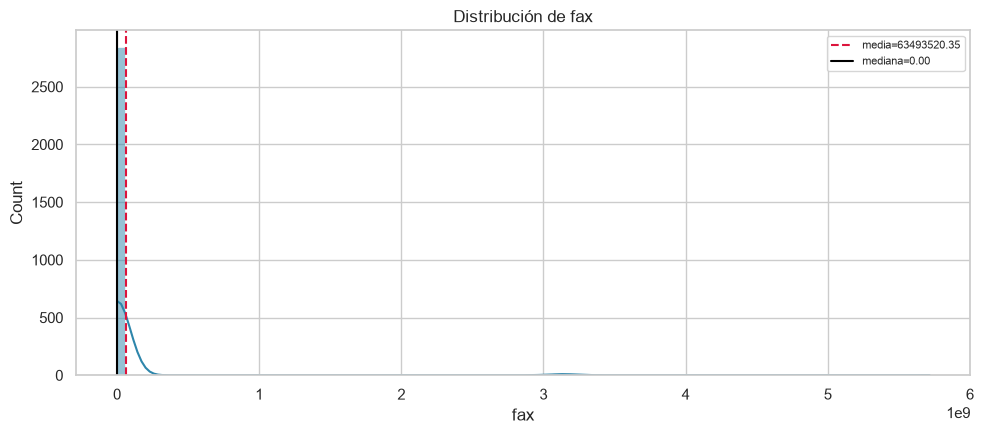

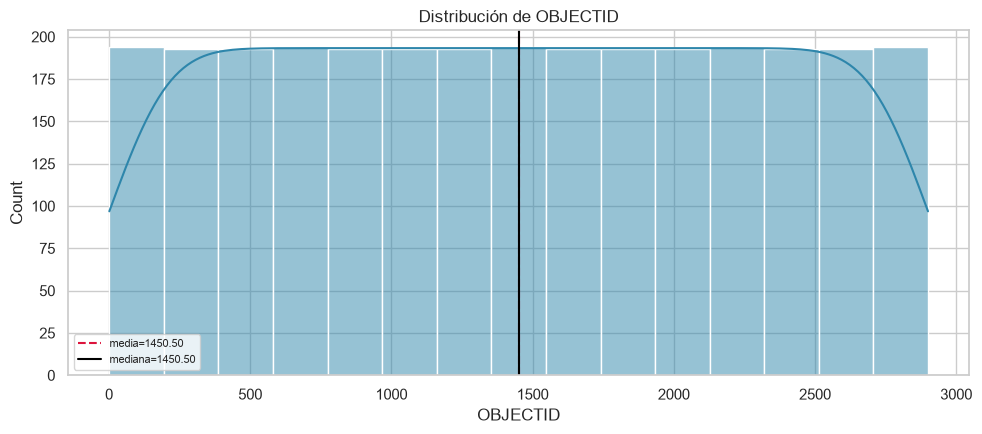

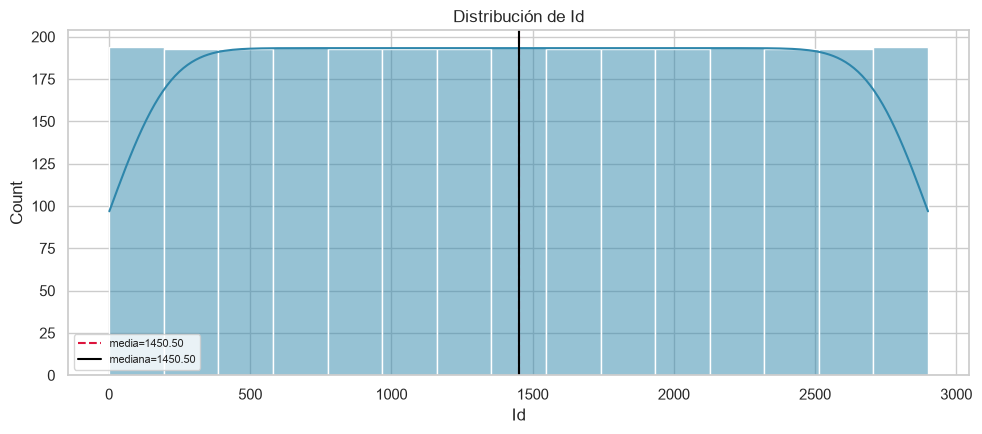

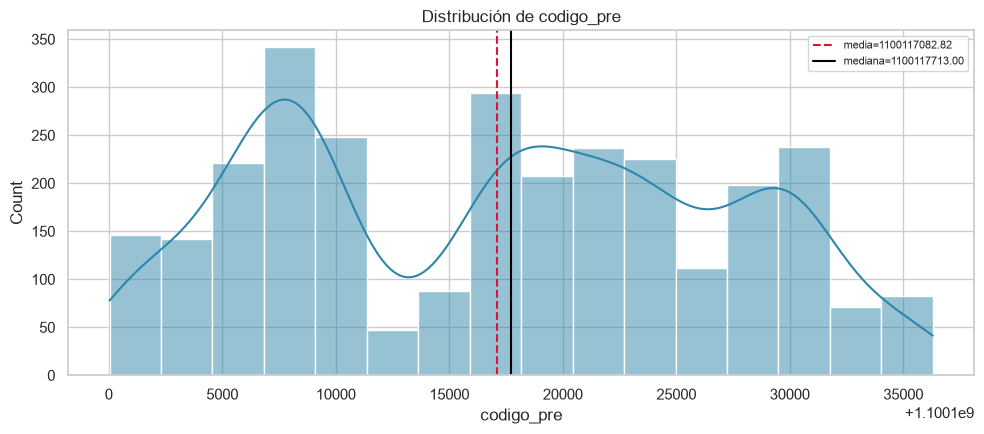

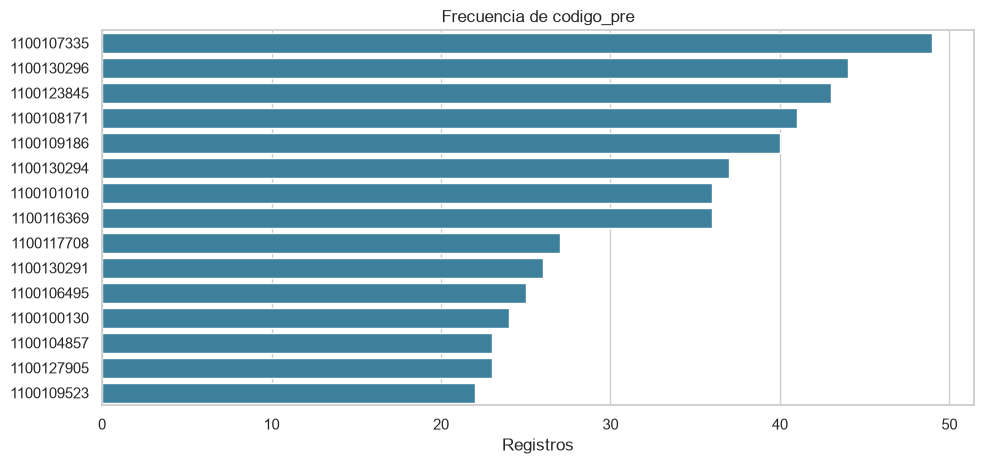

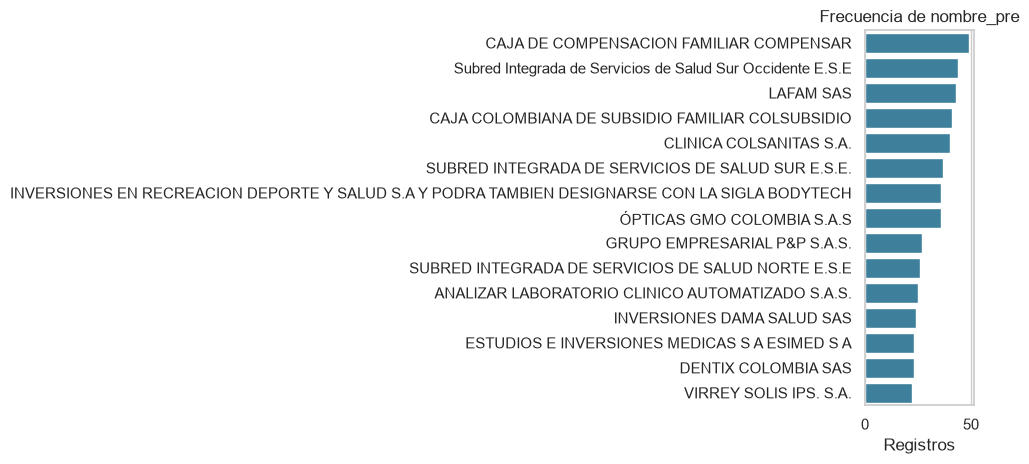

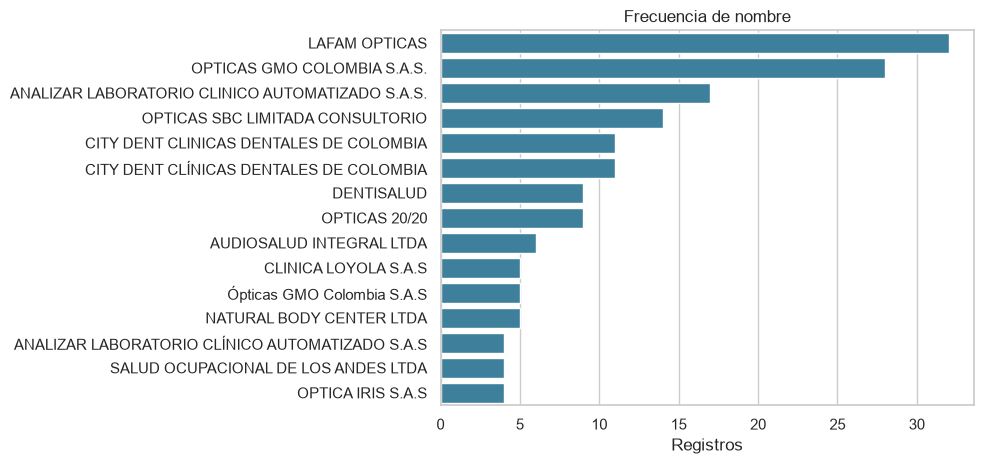

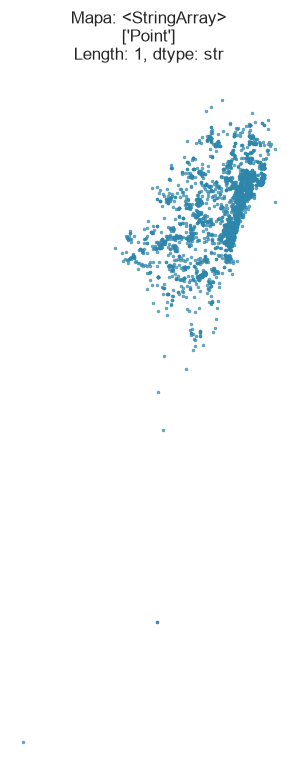

In [3]:
t0('ips_sds')
SPEC = {
    'id': 'ips_sds',
    'titulo': 'IPS georreferenciadas — REPS/SDS',
    'path': 'data/raw/SALUD/ips_sds.gpkg',
    'capa': 'ips',
    'origen': 'Registro Especial de Prestadores de Servicios de Salud (REPS) — Secretaría Distrital de Salud',
    'corte': 'Corte REPS de julio 2020 (columna fecha_cort)',
    'valor_publico': 'Cobertura de servicios de salud por localidad (mediante cruce espacial)',
    'indicadores': 'SAL-01 (IPS por localidad), SAL-02 (camas por habitante)',
    'notas': 'Sin columna de localidad: el conteo territorial se hace con cruce espacial contra la capa Loca del MR. 27 columnas con datos de servicio, horarios y naturaleza.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('ips_sds')


## 2. Camas hospitalarias

### Camas por concepto y naturaleza — OSB

### Camas hospitalarias por concepto y naturaleza — OSB

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,Conceptos,str,categórica nominal,9,15.52,25,Adultos,Atención del Parto,Cuna Básico Neonatal
1,Naturaleza,str,categórica nominal,10,17.24,2,Privada,Pública,
2,Cantidad,float64,numérica continua,14,24.14,41,5611.0,36.0,82.0
3,%,str,categórica nominal,9,15.52,10,"37,00%","0,00%","1,00%"


,columna,n,n_nulos,n_categorias,dominante,pct_dominante,top_5,pct_nulos,n_unicos,media,...,rango,Q1,Q3,IQR,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos
0,Conceptos,49,9,26.0,(nulo),15.52,(nulo)=9 | Adultos=2 | Atención del Parto=2 | ...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Naturaleza,48,10,3.0,Privada,41.38,Privada=24 | Pública=24 | (nulo)=10,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Cantidad,44,14,NaN,NaN,NaN,NaN,24.14,41.0,694.0909,...,15267.0,24.0,280.0,256.0,5.5019,32.2896,349.0105,6.0,13.64,False
3,%,49,9,11.0,"0,00%",44.83,"0,00%=26 | 1,00%=10 | (nulo)=9 | 2,00%=4 | 3,0...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


No hay valores numéricos para Conceptos.
No hay valores numéricos para Naturaleza.
No hay valores numéricos para %.


## Interpretación — Camas hospitalarias por concepto y naturaleza — OSB

**Origen**: Observatorio SISBEN Bogotá (OSB)  
**Corte temporal**: Corte vigente del OSB  
**Valor público**: Dotación de camas (públicas/privadas) para el ratio camas por habitante

**Qué contiene**: 58 filas y 4 columnas; 18.1% de celdas nulas y 8 duplicados.

**Comportamiento de variables numéricas**:
- `Conceptos`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan — nan outliers IQR (nan%)
- `Naturaleza`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan — nan outliers IQR (nan%)
- `Cantidad`: media 694.1, mediana 87.5, desv 2,422.4, rango [3, 15,270], curtosis +32.3 — variabilidad alta (CV=349%); asimetría positiva (+5.50); 6.0 outliers IQR (14%)
- `%`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan — nan outliers IQR (nan%)

**Categóricas dominantes**:
- `Conceptos`: 26.0 categorías; dominante '(nulo)' (16%)
- `Naturaleza`: 3.0 categorías; dominante 'Privada' (41%)
- `%`: 11.0 categorías; dominante '0,00%' (45%)

**Notas / qué falta**: Solo total distrital, sin desagregación por localidad. La columna % está como texto (ej. '37,00%').

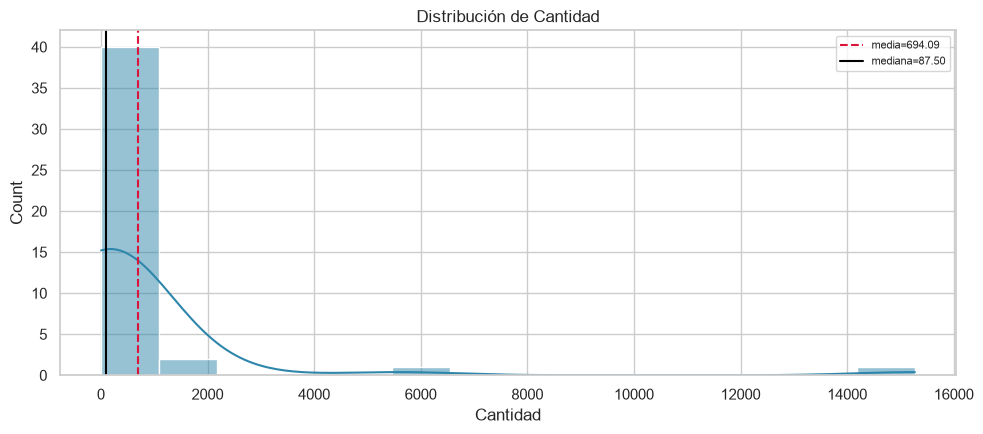

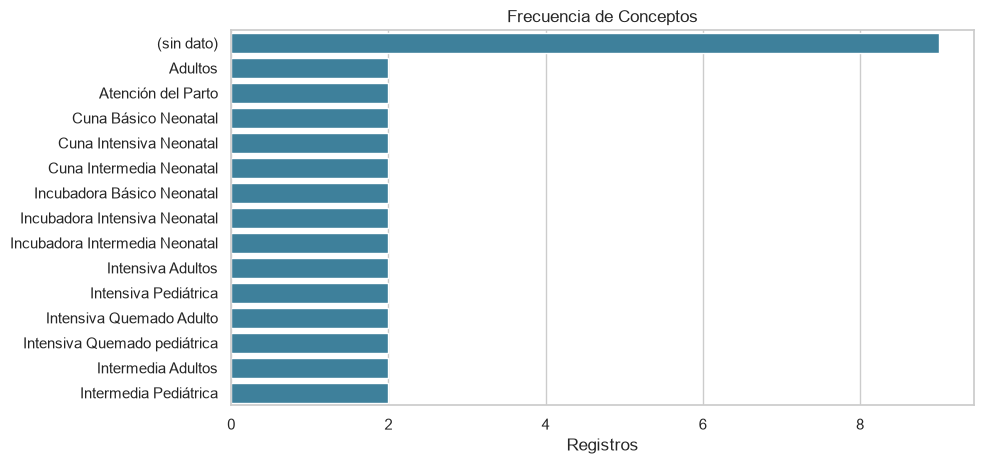

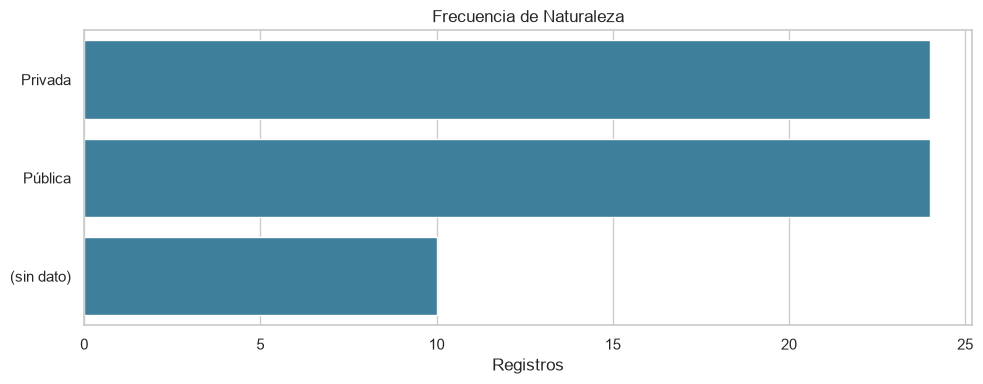

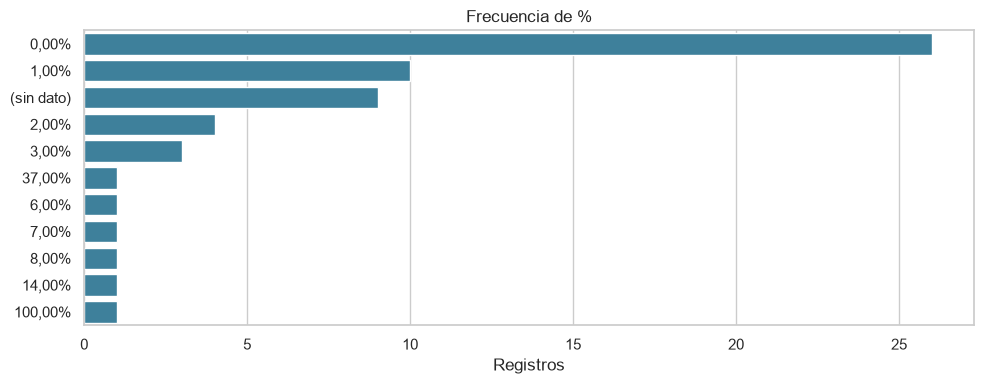

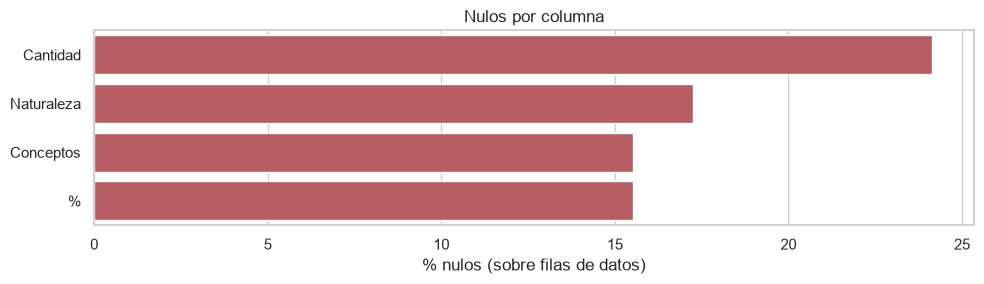

In [4]:
t0('camas')
SPEC = {
    'id': 'camas_sds',
    'titulo': 'Camas hospitalarias por concepto y naturaleza — OSB',
    'path': 'data/raw/SALUD/osb_tiporazoncamas.csv',
    'origen': 'Observatorio SISBEN Bogotá (OSB)',
    'corte': 'Corte vigente del OSB',
    'valor_publico': 'Dotación de camas (públicas/privadas) para el ratio camas por habitante',
    'indicadores': 'SAL-02 (camas por 1.000 habitantes)',
    'notas': "Solo total distrital, sin desagregación por localidad. La columna % está como texto (ej. '37,00%').",
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('camas')


## 3. Análisis de cobertura de salud

### 3.1 IPS por localidad (cruce espacial)

,localidad,n
0,Usaquén,560
1,Chapinero,511
2,Suba,312
3,Teusaquillo,270
4,Barrios Unidos,210
5,Kennedy,193
6,Engativá,172
7,Fontibón,137
8,Puente Aranda,96
9,Santa Fe,78


IPS totales: 2900 | localidades con IPS: 20


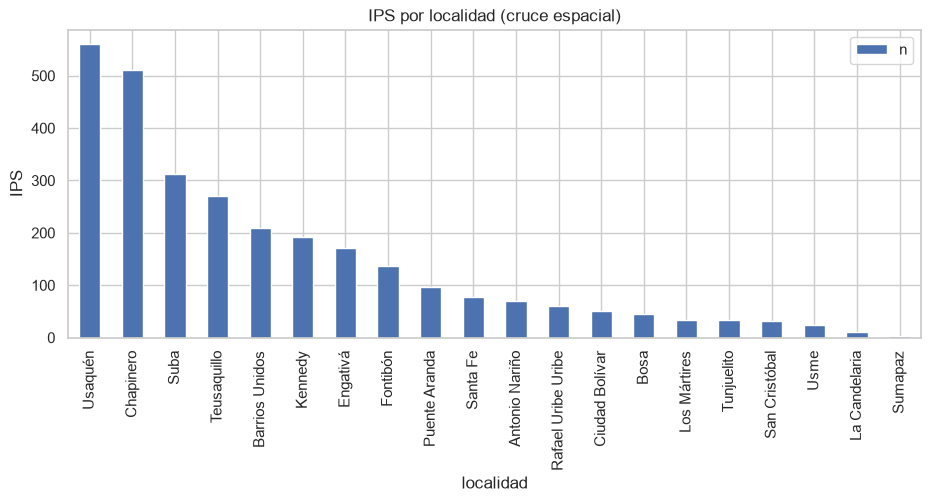

In [5]:
from src.eda.spatial import load_loca, count_points_by_locality
ips = gpd.read_file(str(RAW_DIR / "SALUD" / "ips_sds.gpkg"), layer="ips")
loca = load_loca(MR_PATH)
conteo = count_points_by_locality(ips, loca).sort_values("n", ascending=False).reset_index(drop=True)
conteo.to_csv(REPORTS / "salud_ips_por_localidad.csv", index=False)
display(conteo)
print(f"IPS totales: {len(ips)} | localidades con IPS: {conteo['localidad'].notna().sum()}")
conteo.plot(x="localidad", y="n", kind="bar", figsize=(11, 4), title="IPS por localidad (cruce espacial)", color="#4c72b0")
plt.ylabel("IPS")
plt.show()


### 3.2 Mapa de IPS

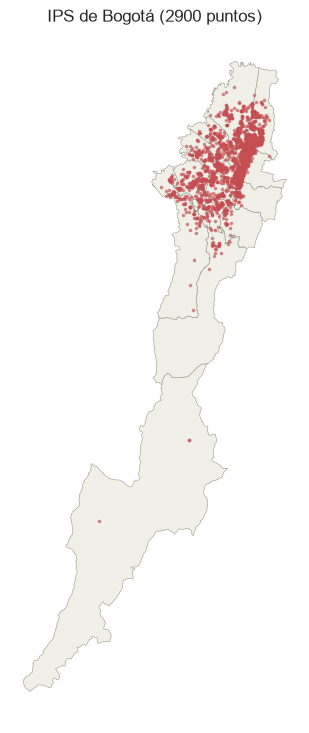

In [6]:
fig, ax = plt.subplots(figsize=(9, 9))
loca.plot(ax=ax, color="#f0f0e8", edgecolor="#9a9a8a", linewidth=0.4)
ips.to_crs(loca.crs).plot(ax=ax, color="#c44e52", markersize=2.5, alpha=0.55)
ax.set_title(f"IPS de Bogotá ({len(ips)} puntos)")
ax.set_axis_off()
plt.show()


### 3.3 Camas por naturaleza y concepto

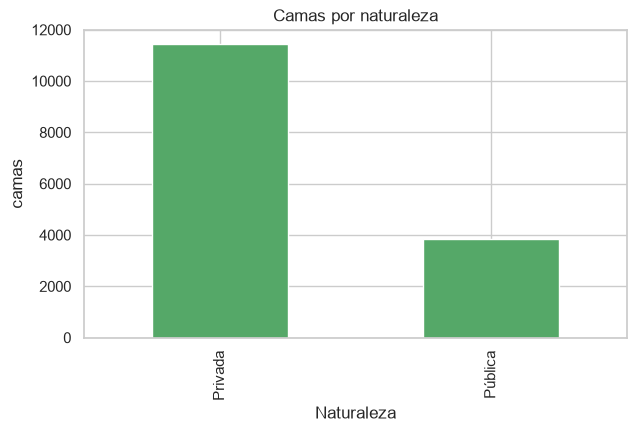

Total camas: 30,540
Top conceptos:
Conceptos
Total                              15270.0
Adultos                             7703.0
Salud Mental Adulto                 1543.0
Pediátrica                          1483.0
Intensiva Adultos                   1077.0
Paciente crónico sin ventilador      514.0
Intermedia Adultos                   508.0
Salud Mental Pediátrico              308.0


In [7]:
camas = eda.read_csv_robust(str(RAW_DIR / "SALUD" / "osb_tiporazoncamas.csv"))[0]
camas["Cantidad"] = pd.to_numeric(camas["Cantidad"], errors="coerce")
total_camas = camas["Cantidad"].sum()
por_nat = camas.groupby("Naturaleza")["Cantidad"].sum().sort_values(ascending=False)
por_nat.plot(kind="bar", figsize=(7, 4), title="Camas por naturaleza", color="#55a868")
plt.ylabel("camas")
plt.show()
print("Total camas:", f"{total_camas:,.0f}")
print("Top conceptos:")
print(camas.groupby("Conceptos")["Cantidad"].sum().sort_values(ascending=False).head(8).round(0).to_string())


### 3.4 Ratio camas por 1.000 habitantes

In [8]:
demo = pd.read_csv(str(RAW_DIR / "DEMOGRAFIA_POBLACION" / "osb_demografia-poblacion-localidad.csv"), sep=";", encoding="utf-8")
demo["POBLACION"] = pd.to_numeric(demo["POBLACION"], errors="coerce")
pob = demo.loc[demo["ANO"] == demo["ANO"].max(), "POBLACION"].sum()
print(f"Población de Bogotá ({int(demo['ANO'].max())}): {pob:,.0f}")
print(f"Camas por 1.000 habitantes: {total_camas / pob * 1000:.2f}")


Población de Bogotá (2035): 15,628,648
Camas por 1.000 habitantes: 1.95


## 4. Indicadores del sector

In [9]:
sts = eda.indicator_status()
sts_sec = sts[sts["indicador"].str.startswith("SAL", na=False)]
display(sts_sec[["indicador", "dimension", "estado", "que_falta"]])
sts_sec.to_csv(REPORTS / "indicadores_salud.csv", index=False)
guardar_tiempos("02_eda_salud.csv")
print("Secciones del notebook:", list(_SECTION_T.keys()))


,indicador,dimension,estado,que_falta


tiempos guardados: 02_eda_salud.csv (2 secciones)
Secciones del notebook: ['ips_sds', 'camas']
